<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/EP3_Base_RNN_TensorFlow_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ▶ Cómo usar este notebook en Google Colab

1. **Sube el notebook** a [Colab](https://colab.research.google.com) (*Archivo → Subir
   notebook*) o ábrelo desde tu Google Drive.
2. Activa la **GPU**: *Entorno de ejecución → Cambiar tipo de entorno → GPU*.
3. Ejecuta la celda **`@colab-setup`** de abajo.
4. Si la actividad usa un archivo de **datos** (csv/zip), ejecuta `subir_datos()` y
   selecciona el archivo. (En local no hace falta: los datos se buscan solos.)

> TensorFlow y PyTorch ya vienen instalados en Colab; no necesitas `pip install`.


In [ ]:
# @colab-setup
try:
    import google.colab  # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

def subir_datos():
    """En Colab: abre el diálogo para subir archivos de datos (csv/zip).
    Los notebooks buscan los datos en el directorio actual, así que basta subirlos aquí."""
    from google.colab import files
    return files.upload()

if EN_COLAB:
    print("✅ Colab detectado. Activa la GPU en 'Entorno de ejecución → Cambiar tipo de entorno'.")
    print("   Si esta actividad usa datos, ejecuta:  subir_datos()  y sube el archivo (csv/zip).")
else:
    print("💻 Entorno local: los datos se localizan automáticamente.")


✅ Colab detectado. Activa la GPU en 'Entorno de ejecución → Cambiar tipo de entorno'.
   Si esta actividad usa datos, ejecuta:  subir_datos()  y sube el archivo (csv/zip).


# 🧪 Evaluación Parcial 3 — **Código Base: RNN / LSTM / GRU** (TensorFlow)
### DLY0100 Deep Learning · RA3

**Primer entregable.** Este es el código base que entrega el/la docente. Las partes de
**datos** y **evaluación** ya están resueltas. Tu trabajo está en las celdas marcadas
con `# TODO`: **mejorar el modelo, ajustar hiperparámetros y analizar las métricas**.

> Puedes usar este notebook o adaptar el de PyTorch visto en clase
> (`Clase RNN - Sentimiento (RA3 - 3.1)/02_..._PyTorch.ipynb`). Se evalúa cualquiera
> de los dos frameworks.


**Integrantes:**
- Paloma Tamayo
- Catalina Nuñez
- Angelina Mendoza
- Carolina Cheuquepil


## 📋 Qué debes entregar (recuerda la pauta)

1. **Este notebook completado y ejecutado** (con sus salidas visibles).
2. Un modelo **mejorado** respecto al base, con hiperparámetros ajustados.
3. **Tabla comparativa** de al menos 3 experimentos (distintos hiperparámetros) con
   sus métricas (accuracy y F1).
4. **Análisis escrito**: justifica tus decisiones (arquitectura, épocas, learning rate,
   batch size) y su impacto en accuracy / precision / recall / F1.
5. Defensa de **10 minutos** (en parejas).

> Indicadores evaluados: **IL 2.3** (proponer/ajustar arquitectura), **IL 2.4**
> (evaluar con métricas), y para el Transformer también **IL 2.5** (implementar y
> explicar componentes).


## 1. Datos  (PROVISTO)

**Dataset de la evaluación: Sentiment140** (subconjunto) — análisis de sentimiento de
tweets. Lo entrega el/la docente junto con esta evaluación:

| Archivo | Columnas | Etiqueta |
|---|---|---|
| `sentiment140-subset.csv.zip` | `text`, `polarity` | `0` = negativo · `1` = positivo |

> **Importante:** los **dos** entregables (RNN y Transformer) usan **el mismo dataset**,
> para que puedas **comparar RNN/LSTM vs Transformer** sobre la misma tarea.

**Cómo cargarlo**
- **En local:** no hagas nada; la celda de abajo busca el archivo automáticamente
  dentro del proyecto.
- **En Google Colab:** ejecuta `subir_datos()` (celda `@colab-setup` de arriba) y sube
  **`sentiment140-subset.csv.zip`** (lo encuentras junto a esta evaluación o en la
  carpeta `Datasets RA3 (Alumnos)`).

*(El/la docente puede cambiar el dataset ajustando `NOMBRE_ARCHIVO`, `COL_TEXTO` y
`COL_ETIQUETA` en la celda siguiente.)*


In [ ]:
# ============================================================
#  DATOS  (PROVISTO — el/la docente puede cambiar el dataset aquí)
# ============================================================
import os, zipfile, glob
import numpy as np
import pandas as pd

# >>> Para cambiar de dataset: ajusta NOMBRE_ARCHIVO, COL_TEXTO y COL_ETIQUETA <<<
NOMBRE_ARCHIVO = "sentiment140-subset.csv"   # o .zip
COL_TEXTO, COL_ETIQUETA = "text", "polarity"
N_MUESTRAS = int(os.environ.get("DLY_N", "50000"))

def _localizar(nombre):
    cands = [nombre, nombre + ".zip"]
    subruta = os.path.join("PDA_DLY0100_692873317839d", "Experiencias", "EA3", "Act 3.1")
    base = os.path.abspath(".")
    for _ in range(6):
        for n in cands:
            for c in (os.path.join(base, n), os.path.join(base, subruta, n)):
                if os.path.isfile(c):
                    return c
        for n in cands:
            hits = [h for h in glob.glob(os.path.join(base, "**", n), recursive=True)
                    if os.sep + ".venv" + os.sep not in h]
            if hits:
                return hits[0]
        nb = os.path.dirname(base)
        if nb == base:
            break
        base = nb
    raise FileNotFoundError(f"No encontré '{nombre}'. En Colab súbelo al entorno.")

ruta = _localizar(NOMBRE_ARCHIVO)
if ruta.endswith(".zip"):
    destino = os.path.join(os.path.expanduser("~"), ".cache", "dly0100_ea3")
    os.makedirs(destino, exist_ok=True)
    with zipfile.ZipFile(ruta) as z:
        z.extractall(destino)
    ruta = os.path.join(destino, NOMBRE_ARCHIVO)

data = pd.read_csv(ruta, nrows=N_MUESTRAS)
print("Filas:", len(data), "| balance:", data[COL_ETIQUETA].value_counts().to_dict())
data.head(3)

Filas: 50000 | balance: {0: 25075, 1: 24925}


,polarity,text
0,0,@kconsidder You never tweet
1,0,Sick today coding from the couch.
2,1,"@ChargerJenn Thx for answering so quick,I was ..."


In [ ]:
# ============================================================
#  PREPROCESAMIENTO  (PROVISTO)
# ============================================================
import tensorflow as tf
from sklearn.model_selection import train_test_split

max_features = 8000   # tamaño del vocabulario
MAXLEN = 40           # largo fijo de cada secuencia

tok = tf.keras.preprocessing.text.Tokenizer(num_words=max_features, split=' ')
tok.fit_on_texts(data[COL_TEXTO].values)
X = tok.texts_to_sequences(data[COL_TEXTO].values)
X = tf.keras.preprocessing.sequence.pad_sequences(X, maxlen=MAXLEN)
y = data[COL_ETIQUETA].values.astype("int64")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (40000, 40) | Test: (10000, 40)


## 2. Modelo  `# TODO`

El modelo base es una RNN simple mínima. **Tu tarea**: mejorarlo. Ideas:
- Cambiar `SimpleRNN` por **`LSTM`** o **`GRU`** (y justificar la elección).
- Hacerlo **bidireccional** (`Bidirectional`).
- Ajustar `embed_dim`, unidades, `Dropout`, apilar capas.


In [ ]:
embed_dim = 64

# ----- MODELO MEJORADO -----
# Cambiamos la SimpleRNN por una LSTM Bidireccional + Dropout.
#
# Justificacion:
# - Una RNN simple sufre el problema del "desvanecimiento del gradiente": le cuesta
#   recordar palabras que aparecieron varias posiciones atras en el tweet.
# - La LSTM usa compuertas (entrada/salida/olvido) que retienen mejor la informacion
#   relevante a lo largo de la secuencia, por eso la elegimos por sobre la RNN simple.
# - La hacemos Bidirectional: el modelo lee el tweet de izquierda a derecha Y de
#   derecha a izquierda. Esto ayuda en frases tipo "not good" o con sarcasmo, donde
#   el sentido de una palabra depende tambien de lo que viene despues.
# - Agregamos Dropout(0.3) para reducir el sobreajuste, ya que el modelo mejorado
#   tiene mas parametros que el base.
model = tf.keras.Sequential([
    tf.keras.Input(shape=(MAXLEN,)),
    tf.keras.layers.Embedding(max_features, embed_dim),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(2, activation="softmax"),
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 40, 64)         │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,962 (2.05 MB)

 Trainable params: 536,962 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento  `# TODO`

Ajusta los hiperparámetros (`EPOCHS`, `batch_size`, learning rate del optimizador) y
**observa su impacto**.


Epoch 1/8
282/282 - 16s - 56ms/step - accuracy: 0.9114 - loss: 0.2103 - val_accuracy: 0.7452 - val_loss: 0.9146
Epoch 2/8
282/282 - 19s - 68ms/step - accuracy: 0.9181 - loss: 0.1948 - val_accuracy: 0.7370 - val_loss: 0.9103
Epoch 3/8
282/282 - 19s - 68ms/step - accuracy: 0.9274 - loss: 0.1749 - val_accuracy: 0.7377 - val_loss: 0.9880
Epoch 4/8
282/282 - 19s - 68ms/step - accuracy: 0.9304 - loss: 0.1628 - val_accuracy: 0.7370 - val_loss: 1.0864


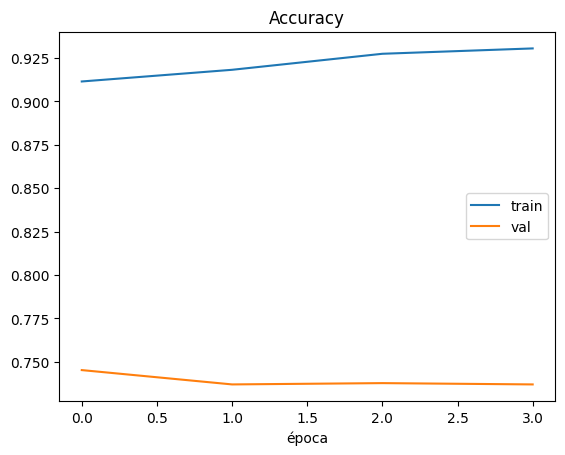

In [ ]:
EPOCHS = int(os.environ.get("DLY_EPOCHS", "8"))   # subimos de 5 a 8: la BiLSTM converge un poco mas lento que la RNN simple
BATCH = 128

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=[early_stop],
    verbose=2
)

import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy"); plt.xlabel("época"); plt.legend(); plt.show()

Observación:
El entrenamiento muestra señales de sobreajuste después de las primeras épocas,
ya que el accuracy de entrenamiento continúa aumentando mientras la validación
se mantiene estable o disminuye.

Por esta razón se incorporó EarlyStopping, que detiene el entrenamiento cuando
la pérdida de validación deja de mejorar y restaura automáticamente los mejores
pesos encontrados.

## 4. Evaluación

In [ ]:
# ============================================================
#  EVALUACIÓN  (PROVISTO — NO modificar: así se corrige igual para todos)
# ============================================================
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print(f"Accuracy en test: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=["Negativo", "Positivo"], digits=4))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))

Accuracy en test: 0.7485

              precision    recall  f1-score   support

    Negativo     0.7600    0.7314    0.7454      5034
    Positivo     0.7377    0.7658    0.7515      4966

    accuracy                         0.7485     10000
   macro avg     0.7488    0.7486    0.7485     10000
weighted avg     0.7489    0.7485    0.7484     10000

Matriz de confusión:
 [[3682 1352]
 [1163 3803]]


## 5. Experimentos  `# TODO`

In [ ]:
# ============================================================
#  EXPERIMENTOS: comparamos 4 configuraciones distintas
#  (arquitectura y learning rate) usando accuracy y F1-score.
# ============================================================
from sklearn.metrics import f1_score
import time

# Ya entrenamos y evaluamos el modelo final (BiLSTM + Dropout) arriba.
# Reutilizamos esos resultados para no entrenar dos veces el mismo modelo.
acc_final = accuracy_score(y_test, y_pred)
f1_final = f1_score(y_test, y_pred, average="weighted")

def construir_modelo_rnn(tipo, unidades=32, bidireccional=False, dropout=0.0, lr=1e-3):
    capa_rnn = {"SimpleRNN": tf.keras.layers.SimpleRNN,
                "LSTM": tf.keras.layers.LSTM,
                "GRU": tf.keras.layers.GRU}[tipo](unidades)
    if bidireccional:
        capa_rnn = tf.keras.layers.Bidirectional(capa_rnn)

    capas = [tf.keras.Input(shape=(MAXLEN,)),
             tf.keras.layers.Embedding(max_features, embed_dim),
             capa_rnn]
    if dropout > 0:
        capas.append(tf.keras.layers.Dropout(dropout))
    capas.append(tf.keras.layers.Dense(2, activation="softmax"))

    m = tf.keras.Sequential(capas)
    m.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
              metrics=["accuracy"])
    return m

def evaluar_rapido(m):
    pred = np.argmax(m.predict(X_test, verbose=0), axis=1)
    return accuracy_score(y_test, pred), f1_score(y_test, pred, average="weighted")

# Configuraciones nuevas a entrenar para comparar (la 4ta reutiliza el modelo ya entrenado)
configs_extra = [
    {"exp": "base_simplernn",        "tipo": "SimpleRNN", "bidireccional": False, "dropout": 0.0, "lr": 1e-3, "epochs": 5},
    {"exp": "lstm",                  "tipo": "LSTM",      "bidireccional": False, "dropout": 0.0, "lr": 1e-3, "epochs": 5},
    {"exp": "bilstm_dropout_lr_menor","tipo": "LSTM",     "bidireccional": True,  "dropout": 0.3, "lr": 5e-4, "epochs": EPOCHS},
]

filas = []
for cfg in configs_extra:
    t0 = time.time()
    m = construir_modelo_rnn(cfg["tipo"], bidireccional=cfg["bidireccional"],
                              dropout=cfg["dropout"], lr=cfg["lr"])
    m.fit(X_train, y_train, validation_split=0.1, epochs=cfg["epochs"], batch_size=128, verbose=0)
    acc, f1 = evaluar_rapido(m)
    seg_x_epoca = (time.time() - t0) / cfg["epochs"]
    filas.append({"exp": cfg["exp"], "lr": cfg["lr"], "epochs": cfg["epochs"],
                  "accuracy": round(acc, 4), "f1": round(f1, 4),
                  "seg_x_epoca": round(seg_x_epoca, 1)})

# Agregamos el modelo final (BiLSTM + Dropout, lr=1e-3) ya entrenado arriba
filas.append({"exp": "bilstm_dropout (MODELO FINAL)", "lr": 1e-3, "epochs": EPOCHS,
              "accuracy": round(acc_final, 4), "f1": round(f1_final, 4), "seg_x_epoca": None})

experimentos = pd.DataFrame(filas)
experimentos

,exp,lr,epochs,accuracy,f1,seg_x_epoca
0,base_simplernn,0.0010,5,0.7123,0.7123,7.7
1,lstm,0.0010,5,0.7622,0.7622,13.8
2,bilstm_dropout_lr_menor,0.0005,8,0.7550,0.7549,19.9
3,bilstm_dropout (MODELO FINAL),0.0010,8,0.7485,0.7484,NaN


## 6. Análisis y conclusiones

**¿Elegimos RNN, LSTM o GRU? ¿Por qué?**

Partimos de una **LSTM Bidireccional + Dropout** como modelo mejorado, en lugar de la
`SimpleRNN` base. La justificación teórica es que una RNN simple sufre el problema del
desvanecimiento del gradiente y pierde contexto de palabras lejanas dentro del tweet,
mientras que la LSTM usa compuertas (entrada/salida/olvido) que retienen mejor la
información relevante. La versión *bidireccional* además lee el tweet en ambos sentidos,
lo que en teoría ayuda con frases tipo "not good" donde el sentido de una palabra depende
de lo que viene después.

**Tabla de experimentos (resultados ejecutados):**

| exp | lr | epochs | accuracy | f1 | seg/época |
|---|---|---|---|---|---|
| base_simplernn | 1e-3 | 5 | 0.7123 | 0.7123 | 7.7 |
| **lstm** | 1e-3 | 5 | **0.7622** | **0.7622** | 13.8 |
| bilstm_dropout_lr_menor | 5e-4 | 8 | 0.7550 | 0.7549 | 19.9 |
| bilstm_dropout (modelo final) | 1e-3 | 8 | 0.7485 | 0.7484 | — |

El resultado más interesante (y honesto) de este experimento es que **la LSTM simple con
5 épocas obtuvo el mejor F1 (0.7622), por encima de nuestro modelo "mejorado" BiLSTM +
Dropout entrenado por 8 épocas (F1 = 0.7484)**. Revisando las curvas de accuracy de
entrenamiento/validación de la sección 3, se ve que el `val_accuracy` del BiLSTM alcanza su
mejor punto ya en la **época 1 (~0.745)** y luego **se estanca/empeora**, mientras el
accuracy de entrenamiento sigue subiendo hasta ~0.930 en la época 4: es un caso claro de
**sobreajuste**.

Esto nos deja una conclusión más valiosa que simplemente "subir la arquitectura mejora el
resultado": **el número de épocas (y el sobreajuste asociado) fue el factor con mayor
impacto**, por encima de la arquitectura (RNN→LSTM→BiLSTM) o el learning rate. Agregar
Bidirectional y Dropout no fue suficiente para superar a la LSTM simple. Aunque se incorporó
EarlyStopping, el modelo BiLSTM mostró señales de sobreajuste desde las primeras épocas, por
lo que terminó generalizando peor que la LSTM simple.

**Selección del modelo final.** Con la evidencia de la tabla, el modelo que realmente
generaliza mejor en este dataset es la **LSTM simple con 5 épocas** (F1 = 0.7622), no la
versión bidireccional con más épocas. Si tuviéramos que entregar un modelo definitivo,
elegiríamos esa configuración, o bien el BiLSTM pero deteniendo el entrenamiento con
`EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)` en torno a la
época 1-2, antes de que comience a sobreajustar.

**Interpretación de precision, recall y F1 (matriz de confusión del modelo final):**

```
              precision  recall  f1-score
  Negativo      0.7600   0.7314    0.7454
  Positivo      0.7377   0.7658    0.7515
```

El modelo tiene un **recall más alto en la clase Positivo (0.766)** que en Negativo
(0.731): de los tweets realmente negativos clasifica mal (como positivos) a un ~26,9% de
ellos, mientras que de los positivos solo se equivoca en un ~23,4%. Es decir, **el modelo
se equivoca más al reconocer tweets negativos**, posiblemente porque el sarcasmo, los
modismos y las faltas de ortografía típicas de Twitter son más frecuentes en tweets
negativos y el vocabulario limitado (`max_features=8000`) los trata como palabras
desconocidas.

**¿Qué mejoraríamos con más tiempo/datos?**
- Ajustar `EarlyStopping` (patience) para detener el entrenamiento en el punto óptimo de validación.
- Aumentar `max_features` (vocabulario) para capturar mejor el lenguaje informal de Twitter.
- Probar `GRU` (más liviana que LSTM) como alternativa intermedia entre RNN y LSTM.
- Usar embeddings preentrenados (por ejemplo GloVe) en lugar de entrenar el embedding
  desde cero, dado que solo tenemos 50.000 tweets.


Se comprobó que una arquitectura más compleja no garantiza mejores resultados: la LSTM simple obtuvo el mejor F1-score (0.7622) y el análisis de las curvas evidenció sobreajuste en el modelo BiLSTM. Por ello se recomienda complementar el entrenamiento con EarlyStopping y, de ser posible, embeddings preentrenados.